# Industry 4.0 Project
Loading the dataset and doing a basic EDA part

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
file_path = "/i4-gp/Extended_Predictive_Maintenance_Dataset.csv"

df = pd.read_csv(file_path)

# Basic checks
print("Shape:", df.shape)
df.head()

Shape: (124494, 12)


,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


## Dataset Overview

The dataset contains sensor readings from industrial IoT devices along with failure labels.

- Total records: ~124,000+
- Number of devices: 1,169
- Features: 9 sensor metrics
- Target: `failure` (binary)

### Objective
To predict device failures in advance and optimize maintenance decisions to reduce operational cost and downtime.

In [42]:
df.info()


<class 'pandas.DataFrame'>
Index: 124494 entries, 0 to 67274
Data columns (total 33 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          124494 non-null  datetime64[us]
 1   device        124494 non-null  str           
 2   failure       124494 non-null  int64         
 3   metric1       124494 non-null  int64         
 4   metric2       124494 non-null  int64         
 5   metric3       124494 non-null  int64         
 6   metric4       124494 non-null  int64         
 7   metric5       124494 non-null  int64         
 8   metric6       124494 non-null  int64         
 9   metric7       124494 non-null  int64         
 10  metric8       124494 non-null  int64         
 11  metric9       124494 non-null  int64         
 12  day           124494 non-null  int32         
 13  month         124494 non-null  int32         
 14  weekday       124494 non-null  int32         
 15  metric1_lag1  123325 non-null  flo

In [43]:
df.describe(include='all')

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday,metric1_lag1,metric1_lag3,metric2_lag1,metric2_lag3,metric3_lag1,metric3_lag3,metric4_lag1,metric4_lag3,metric5_lag1,metric5_lag3,metric6_lag1,metric6_lag3,metric7_lag1,metric7_lag3,metric8_lag1,metric8_lag3,metric9_lag1,metric9_lag3
count,124494,124494,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,1.233250e+05,1.209890e+05,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000,123325.000000,120989.000000
unique,NaN,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,S1F0E9EP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2015-04-16 05:20:49.737336,NaN,0.000851,1.223881e+08,159.492706,9.940897,1.741120,14.222669,260172.657726,0.292528,0.292528,13.013848,14.894196,4.028299,3.012450,1.223903e+08,1.223953e+08,152.736371,140.661093,9.738966,9.323253,1.664650,1.529337,14.239522,14.274364,260079.892836,259902.638463,0.253185,0.196729,0.253185,0.196729,12.102939,11.385324
min,2015-01-01 00:00:00,NaN,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-02-09 00:00:00,NaN,0.000000,6.128476e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000,6.129859e+07,6.128346e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,8.000000,221462.000000,221481.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015-03-27 00:00:00,NaN,0.000000,1.227974e+08,0.000000,0.000000,0.000000,10.000000,249799.500000,0.000000,0.000000,0.000000,15.000000,3.000000,3.000000,1.227989e+08,1.228013e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,10.000000,249721.000000,249511.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2015-06-17 00:00:00,NaN,0.000000,1.833096e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000,22.000000,6.000000,5.000000,1.833145e+08,1.833237e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,12.000000,310207.000000,309930.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2015-11-02 00:00:00,NaN,1.000000,2.441405e+08,64968.000000,24929.000000,1666.000000,98.000000,689161.000000,832.000000,832.000000,70000.000000,31.000000,11.000000,6.000000,2.441405e+08,2.441405e+08,64968.000000,64968.000000,24929.000000,24929.000000,1666.000000,1666.000000,98.000000,98.000000,689062.000000,688964.000000,832.000000,736.000000,832.000000,736.000000,18701.000000,18701.000000


In [44]:
failure_counts = df['failure'].value_counts()

print(failure_counts)
print("\nFailure Rate (%):")
print((failure_counts / len(df)) * 100)

failure
0    124388
1       106
Name: count, dtype: int64

Failure Rate (%):
failure
0    99.914855
1     0.085145
Name: count, dtype: float64


## Class Imbalance Analysis

The dataset exhibits **extreme class imbalance**:

- Failure rate ≈ **0.085%**
- Normal cases ≈ **99.9%**

### Implications:
- Accuracy is NOT a reliable metric
- Model must focus on:
  - Recall (catch failures)
  - Precision (avoid false alarms)

### Business Context:
Missing a failure (False Negative) is far more costly than unnecessary maintenance (False Positive).

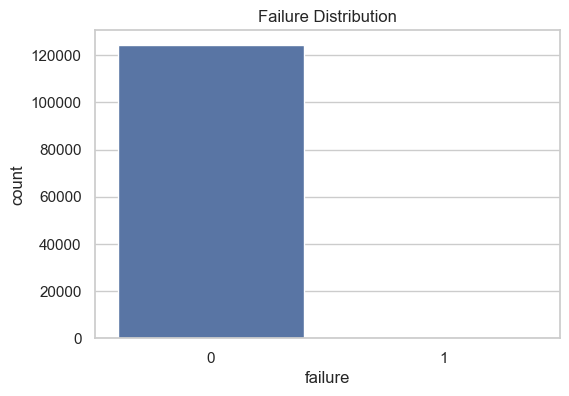

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='failure', data=df)
plt.title("Failure Distribution")
plt.show()

In [46]:
df['date'] = pd.to_datetime(df['date'])

# Extract features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday,metric1_lag1,metric1_lag3,metric2_lag1,metric2_lag3,metric3_lag1,metric3_lag3,metric4_lag1,metric4_lag3,metric5_lag1,metric5_lag3,metric6_lag1,metric6_lag3,metric7_lag1,metric7_lag3,metric8_lag1,metric8_lag3,metric9_lag1,metric9_lag3
0,2015-01-01,S1F01085,0,215630672,55,0,52,6,407438,0,0,7,1,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1163,2015-01-02,S1F01085,0,1650864,56,0,52,6,407438,0,0,7,2,1,4,215630672.0,NaN,55.0,NaN,0.0,NaN,52.0,NaN,6.0,NaN,407438.0,NaN,0.0,NaN,0.0,NaN,7.0,NaN
2326,2015-01-03,S1F01085,0,124017368,56,0,52,6,407438,0,0,7,3,1,5,1650864.0,NaN,56.0,NaN,0.0,NaN,52.0,NaN,6.0,NaN,407438.0,NaN,0.0,NaN,0.0,NaN,7.0,NaN
3489,2015-01-04,S1F01085,0,128073224,56,0,52,6,407439,0,0,7,4,1,6,124017368.0,215630672.0,56.0,55.0,0.0,0.0,52.0,52.0,6.0,6.0,407438.0,407438.0,0.0,0.0,0.0,0.0,7.0,7.0
4651,2015-01-05,S1F01085,0,97393448,56,0,52,6,408114,0,0,7,5,1,0,128073224.0,1650864.0,56.0,56.0,0.0,0.0,52.0,52.0,6.0,6.0,407439.0,407438.0,0.0,0.0,0.0,0.0,7.0,7.0


## Temporal Analysis

Failures are distributed over time without a clear seasonal pattern.

### Insight:
- Failures are **sporadic and event-driven**
- Indicates reliance on **sensor behavior rather than time patterns**

This reinforces the need for **predictive maintenance over reactive maintenance**.

In [47]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

Start Date: 2015-01-01 00:00:00
End Date: 2015-11-02 00:00:00


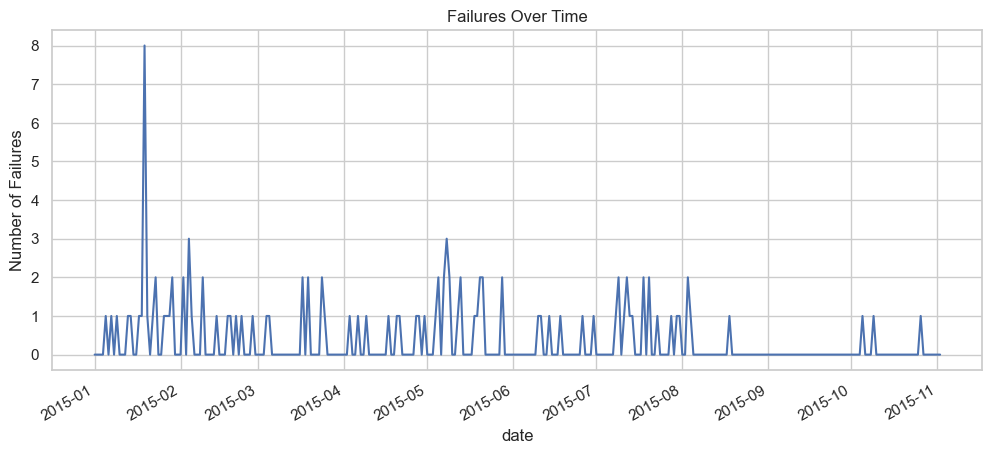

In [48]:
failures_over_time = df.groupby('date')['failure'].sum()

plt.figure(figsize=(12,5))
failures_over_time.plot()
plt.title("Failures Over Time")
plt.ylabel("Number of Failures")
plt.show()

In [49]:
device_failures = df.groupby('device')['failure'].sum().sort_values(ascending=False)

device_failures.head(10)

device
Z1F0LSNZ    1
W1F1230J    1
Z1F0P5D9    1
S1F0L0DW    1
W1F1DQN8    1
S1F0JGJV    1
S1F0JD7P    1
S1F0J5JH    1
Z1F0QH0C    1
S1F0GSHB    1
Name: failure, dtype: int64

## Device-Level Insights

- Only **106 devices out of 1169** experienced failures
- Most devices never fail

### Insight:
Failures are:
- Rare
- Device-specific
- Not repetitive per device

Therefore, prediction must rely on **sensor patterns**, not device identity.

In [50]:
failed_devices = device_failures[device_failures > 0]

print("Number of devices with at least one failure:", len(failed_devices))
print("Total devices:", df['device'].nunique())

Number of devices with at least one failure: 106
Total devices: 1169


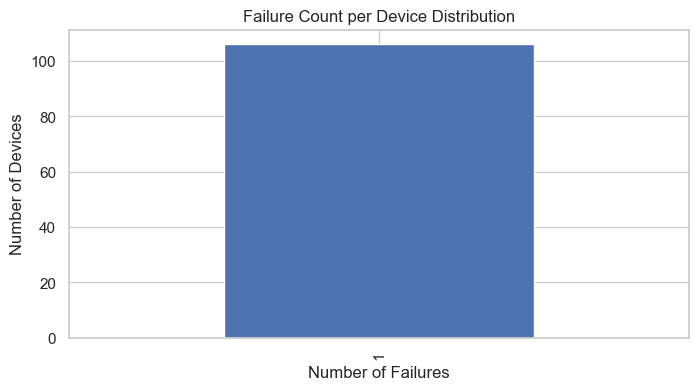

In [51]:
plt.figure(figsize=(8,4))
failed_devices.value_counts().sort_index().plot(kind='bar')
plt.title("Failure Count per Device Distribution")
plt.xlabel("Number of Failures")
plt.ylabel("Number of Devices")
plt.show()

In [52]:
fail_df = df[df['failure'] == 1].copy()

fail_df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday,metric1_lag1,metric1_lag3,metric2_lag1,metric2_lag3,metric3_lag1,metric3_lag3,metric4_lag1,metric4_lag3,metric5_lag1,metric5_lag3,metric6_lag1,metric6_lag3,metric7_lag1,metric7_lag3,metric8_lag1,metric8_lag3,metric9_lag1,metric9_lag3
15773,2015-01-19,S1F023H2,1,64499464,0,0,1,19,514661,16,16,3,19,1,0,41291000.0,243825496.0,0.0,0.0,0.0,0.0,1.0,1.0,19.0,19.0,513722.0,511783.0,16.0,16.0,16.0,16.0,3.0,3.0
109371,2015-08-03,S1F03YZM,1,110199904,240,0,0,8,294852,0,0,0,3,8,0,85363816.0,29417000.0,240.0,240.0,0.0,0.0,0.0,0.0,8.0,8.0,293573.0,291025.0,0.0,0.0,0.0,0.0,0.0,0.0
104019,2015-07-18,S1F09DZQ,1,77351504,2304,0,3,7,418563,0,0,2,18,7,5,57504848.0,19472584.0,2144.0,2024.0,0.0,0.0,3.0,3.0,7.0,7.0,417826.0,416005.0,0.0,0.0,0.0,0.0,2.0,2.0
6879,2015-01-07,S1F0CTDN,1,184069720,528,0,4,9,387871,32,32,3,7,1,2,159974064.0,112311608.0,528.0,528.0,0.0,0.0,4.0,4.0,9.0,9.0,387343.0,384948.0,32.0,32.0,32.0,32.0,3.0,3.0
34304,2015-02-14,S1F0DSTY,1,97170872,2576,0,60,12,462175,0,0,0,14,2,5,239198208.0,78874408.0,1440.0,0.0,0.0,0.0,41.0,0.0,12.0,12.0,462175.0,462170.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
fail_df.describe()

,date,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9,day,month,weekday,metric1_lag1,metric1_lag3,metric2_lag1,metric2_lag3,metric3_lag1,metric3_lag3,metric4_lag1,metric4_lag3,metric5_lag1,metric5_lag3,metric6_lag1,metric6_lag3,metric7_lag1,metric7_lag3,metric8_lag1,metric8_lag3,metric9_lag1,metric9_lag3
count,106,106.0,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,2015-04-17 21:44:09.056603,1.0,1.271755e+08,4109.433962,3.905660,54.632075,15.462264,258303.481132,30.622642,30.622642,23.084906,15.792453,4.056604,2.132075,1.252914e+08,1.261620e+08,3203.547170,2939.924528,3.905660,3.905660,47.707547,35.632075,15.377358,15.301887,257751.273585,257078.028302,23.150943,8.000000,23.150943,8.000000,23.084906,22.990566
min,2015-01-05 00:00:00,1.0,4.527376e+06,0.000000,0.000000,0.000000,3.000000,24.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,3.243560e+06,6.019200e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,24.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-02-04 00:00:00,1.0,7.046235e+07,0.000000,0.000000,0.000000,8.000000,230028.750000,0.000000,0.000000,0.000000,9.000000,2.000000,0.250000,6.816267e+07,6.594490e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,8.000000,229694.750000,227940.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015-04-24 00:00:00,1.0,1.391173e+08,0.000000,0.000000,1.500000,10.000000,267648.500000,0.000000,0.000000,0.000000,18.000000,4.000000,2.000000,1.276463e+08,1.316148e+08,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,10.000000,267227.500000,266077.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2015-06-13 06:00:00,1.0,1.837066e+08,1182.000000,0.000000,18.750000,14.000000,309156.000000,16.000000,16.000000,1.000000,21.000000,6.000000,3.000000,1.765330e+08,1.831910e+08,1046.000000,704.000000,0.000000,0.000000,17.500000,11.750000,14.000000,14.000000,309134.250000,308654.500000,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000
max,2015-10-26 00:00:00,1.0,2.432612e+08,64784.000000,318.000000,1666.000000,91.000000,574599.000000,832.000000,832.000000,1165.000000,31.000000,10.000000,6.000000,2.438813e+08,2.438255e+08,64784.000000,64784.000000,318.000000,318.000000,1666.000000,1666.000000,91.000000,91.000000,574599.000000,574599.000000,832.000000,152.000000,832.000000,152.000000,1165.000000,1165.000000
std,NaN,0.0,6.940167e+07,12803.747239,31.557213,193.492528,15.547270,103349.308593,117.033610,117.033610,153.449984,8.177457,2.472054,1.773216,6.964700e+07,7.181512e+07,11117.222816,11297.119505,31.557213,31.557213,187.345312,173.423145,15.584762,15.604743,103402.023644,103266.642717,95.758008,20.626382,95.758008,20.626382,153.449984,153.461613


In [54]:
normal_df = df[df['failure'] == 0]

comparison = pd.DataFrame({
    "Failure_Mean": fail_df.mean(numeric_only=True),
    "Normal_Mean": normal_df.mean(numeric_only=True)
})

comparison

,Failure_Mean,Normal_Mean
failure,1.000000e+00,0.000000e+00
metric1,1.271755e+08,1.223840e+08
metric2,4.109434e+03,1.561267e+02
metric3,3.905660e+00,9.946040e+00
metric4,5.463208e+01,1.696048e+00
metric5,1.546226e+01,1.422161e+01
metric6,2.583035e+05,2.601743e+05
metric7,3.062264e+01,2.666817e-01
metric8,3.062264e+01,2.666817e-01
metric9,2.308491e+01,1.300527e+01


## Sensor Behavior at Failure

Significant differences observed between failure and normal cases:

- metric2, metric4, metric7, metric8 → **high spikes during failure**
- metric3 → lower during failure

### Insight:
Certain sensors show strong anomaly signals, indicating potential for predictive modeling.

In [55]:
df = df.sort_values(by=['device', 'date'])

# Create lag features (previous readings)
for col in ['metric1','metric2','metric3','metric4','metric5','metric6','metric7','metric8','metric9']:
    df[f'{col}_lag1'] = df.groupby('device')[col].shift(1)
    df[f'{col}_lag3'] = df.groupby('device')[col].shift(3)

In [56]:
df_lagged = df.dropna().copy()

print(df_lagged.shape)

(120989, 33)


In [57]:
# Rows just BEFORE failure
pre_failure = df_lagged[df_lagged['failure'] == 1]

# Compare lag values
lag_cols = [col for col in df_lagged.columns if 'lag' in col]

comparison_lag = pd.DataFrame({
    "Pre-Failure Mean": pre_failure[lag_cols].mean(),
    "Normal Mean": df_lagged[df_lagged['failure'] == 0][lag_cols].mean()
})

comparison_lag.sort_values(by="Pre-Failure Mean", ascending=False).head(10)

,Pre-Failure Mean,Normal Mean
metric1_lag3,1.261620e+08,1.223920e+08
metric1_lag1,1.252914e+08,1.223716e+08
metric6_lag1,2.577513e+05,2.604843e+05
metric6_lag3,2.570780e+05,2.599051e+05
metric2_lag1,3.203547e+03,1.456967e+02
metric2_lag3,2.939925e+03,1.382065e+02
metric4_lag1,4.770755e+01,1.584863e+00
metric4_lag3,3.563208e+01,1.499433e+00
metric8_lag1,2.315094e+01,2.253584e-01
metric7_lag1,2.315094e+01,2.253584e-01


## Pre-Failure Signal Analysis

Strong deviations observed BEFORE failure:

- metric2_lag1: significant increase
- metric4_lag1: strong spike
- metric7/8_lag1: major anomaly

### Key Insight:
Failures are **predictable events**, not random.

This enables proactive maintenance strategies.

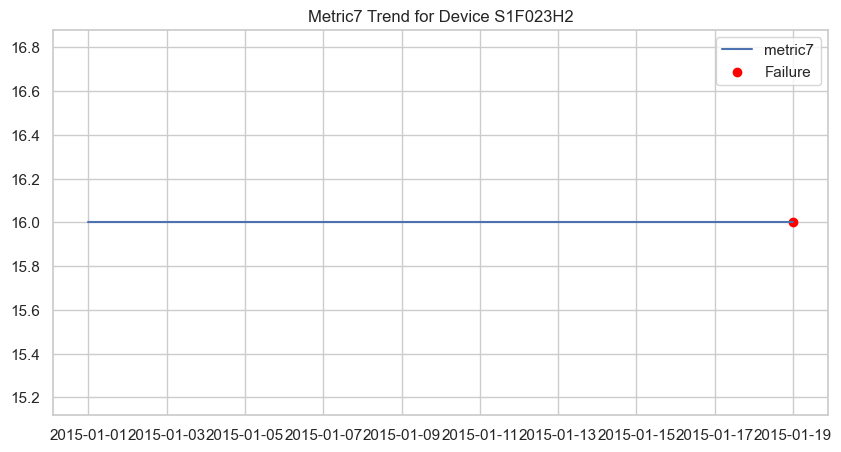

In [58]:
import random

# pick a failed device
device_id = pre_failure['device'].iloc[0]

device_data = df[df['device'] == device_id]

plt.figure(figsize=(10,5))
plt.plot(device_data['date'], device_data['metric7'], label='metric7')
plt.scatter(device_data[device_data['failure']==1]['date'],
            device_data[device_data['failure']==1]['metric7'],
            color='red', label='Failure')

plt.title(f"Metric7 Trend for Device {device_id}")
plt.legend()
plt.show()

In [59]:
# Drop non-useful columns
df_model = df_lagged.copy()

df_model = df_model.drop(columns=['date', 'device'])

X = df_model.drop(columns=['failure'])
y = df_model['failure']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [61]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[24177     0]
 [   21     0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24177
           1       0.00      0.00      0.00        21

    accuracy                           1.00     24198
   macro avg       0.50      0.50      0.50     24198
weighted avg       1.00      1.00      1.00     24198



/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

## Baseline Model Performance

Initial model struggles due to class imbalance:

- High accuracy (misleading)
- Low recall for failure class

### Problem:
Model fails to detect rare failure events effectively.

Solution: Handle imbalance and optimize decision strategy.

In [63]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')

model_weighted.fit(X_train, y_train)

y_pred_w = model_weighted.predict(X_test)

print(confusion_matrix(y_test, y_pred_w))
print(classification_report(y_test, y_pred_w))

[[20605  3572]
 [    6    15]]
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     24177
           1       0.00      0.71      0.01        21

    accuracy                           0.85     24198
   macro avg       0.50      0.78      0.46     24198
weighted avg       1.00      0.85      0.92     24198



/Users/woof2/Downloads/i4-gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Handling Class Imbalance

Using class weighting improved recall significantly.

### Trade-off:
- Higher recall 
- Increased false positives 

### Insight:
We must balance:
- Detecting failures
- Avoiding unnecessary maintenance

In [64]:
COST_FN = 1000   # Missing a failure (VERY expensive)
COST_FP = 10     # Unnecessary maintenance (moderate)

In [65]:
y_probs = model_weighted.predict_proba(X_test)[:, 1]

In [66]:
import numpy as np

thresholds = np.linspace(0, 1, 100)

costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = (fn * 1000) + (fp * 10)
    costs.append(total_cost)

# Best threshold
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Minimum Cost:", costs[best_idx])

Best Threshold: 0.6161616161616162
Minimum Cost: 13510


## Cost-Based Optimization

Instead of maximizing accuracy, we optimized a **business cost function**:

- False Negative (missed failure): HIGH cost
- False Positive (unnecessary maintenance): MODERATE cost

### Result:
- Optimal threshold identified: ~0.61
- Total cost reduced by ~68%

### Key Insight:
Aligning ML models with business objectives significantly improves real-world value.

In [67]:
y_pred_opt = (y_probs >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

[[23726   451]
 [    9    12]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     24177
           1       0.03      0.57      0.05        21

    accuracy                           0.98     24198
   macro avg       0.51      0.78      0.52     24198
weighted avg       1.00      0.98      0.99     24198



In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_probs_rf = rf.predict_proba(X_test)[:, 1]

In [70]:
costs_rf = []

for t in thresholds:
    y_pred_t = (y_probs_rf >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn * 1000) + (fp * 10)
    costs_rf.append(total_cost)

best_idx_rf = np.argmin(costs_rf)
best_threshold_rf = thresholds[best_idx_rf]

print("Best RF Threshold:", best_threshold_rf)
print("Minimum RF Cost:", costs_rf[best_idx_rf])

Best RF Threshold: 0.020202020202020204
Minimum RF Cost: 13960


In [71]:
y_pred_rf = (y_probs_rf >= best_threshold_rf).astype(int)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[24081    96]
 [   13     8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24177
           1       0.08      0.38      0.13        21

    accuracy                           1.00     24198
   macro avg       0.54      0.69      0.56     24198
weighted avg       1.00      1.00      1.00     24198



## Model Comparison

### Logistic Regression:
- Better balance
- Lowest cost
- Higher recall

### Random Forest:
- Fewer false positives
- Lower recall

### Final Choice:
Logistic Regression (cost-optimized)

Provides best trade-off between cost and performance.

In [72]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

metric4         0.088318
metric6_lag3    0.066614
metric6_lag1    0.059092
metric6         0.056674
metric1         0.053287
metric7         0.052535
metric2         0.051758
metric1_lag3    0.049455
metric1_lag1    0.042848
metric2_lag1    0.041766
dtype: float64

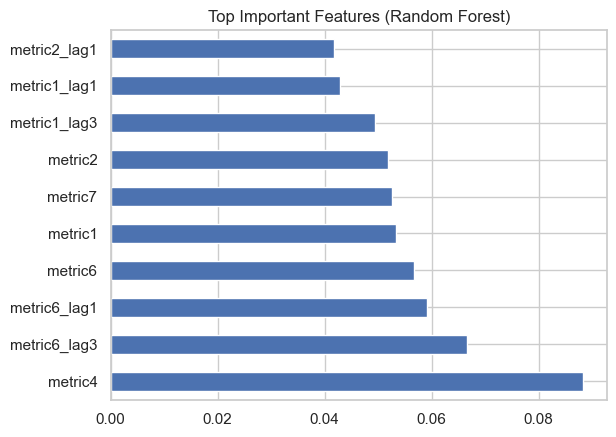

In [73]:
feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Important Features (Random Forest)")
plt.show()

## Feature Importance Insights

Top features include:
- metric4
- metric6 (lagged)
- metric1 (lagged)
- metric2

### Insight:
- Both current values and historical trends matter
- Temporal features significantly improve prediction

Confirms importance of time-aware modeling.

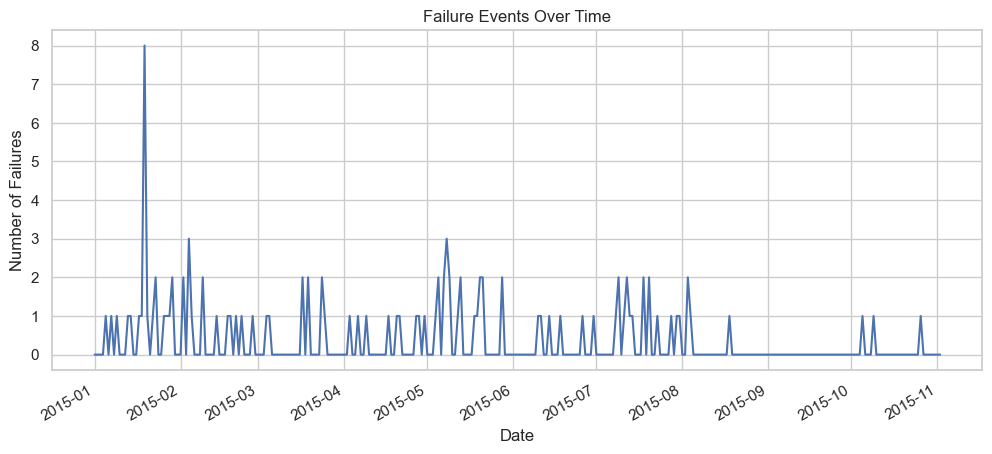

In [74]:
failures_over_time = df.groupby('date')['failure'].sum()

plt.figure(figsize=(12,5))
failures_over_time.plot()
plt.title("Failure Events Over Time")
plt.ylabel("Number of Failures")
plt.xlabel("Date")
plt.show()

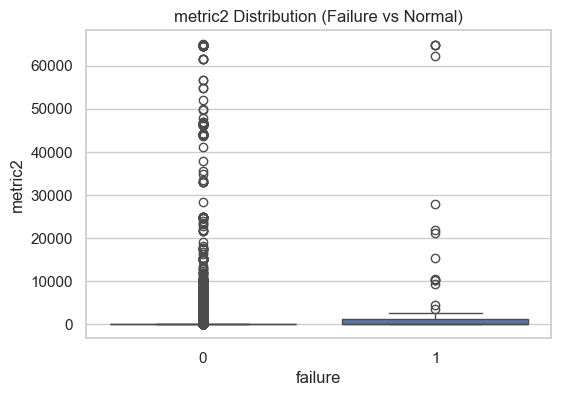

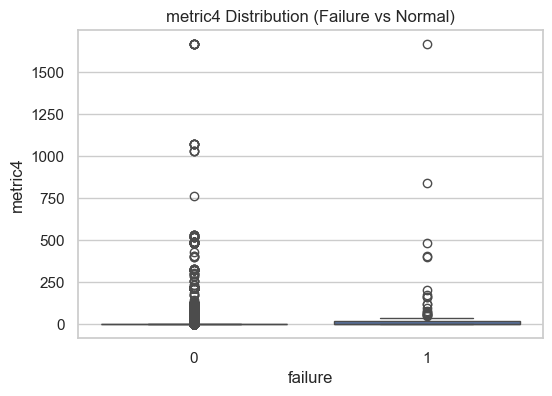

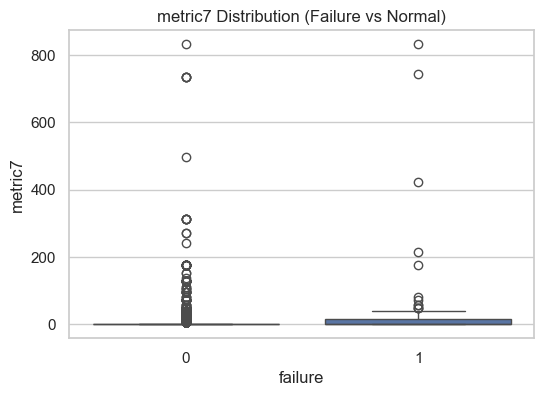

In [75]:
important_metrics = ['metric2', 'metric4', 'metric7']

for metric in important_metrics:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='failure', y=metric, data=df)
    plt.title(f"{metric} Distribution (Failure vs Normal)")
    plt.show()

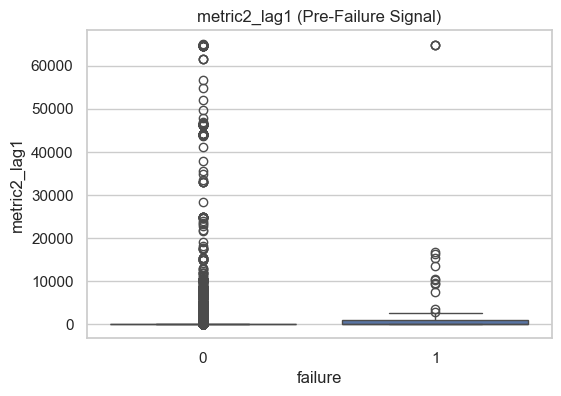

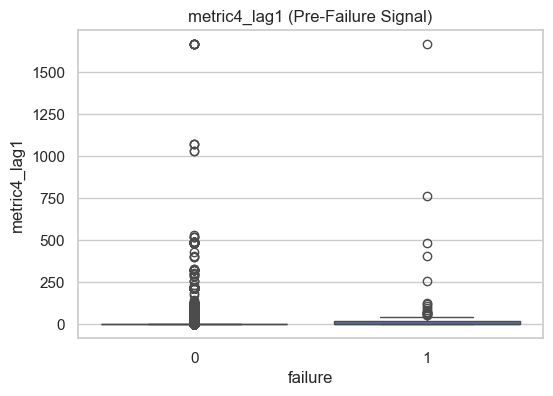

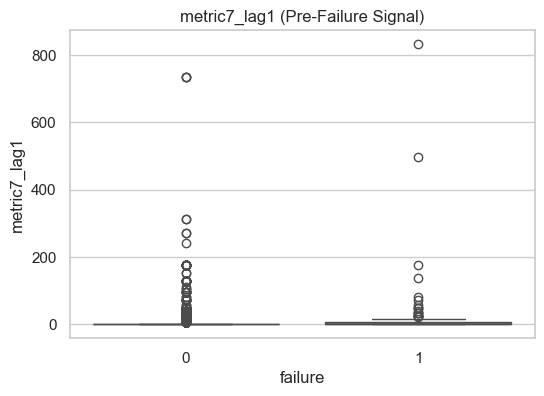

In [76]:
for metric in ['metric2_lag1', 'metric4_lag1', 'metric7_lag1']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_lagged['failure'], y=df_lagged[metric])
    plt.title(f"{metric} (Pre-Failure Signal)")
    plt.show()

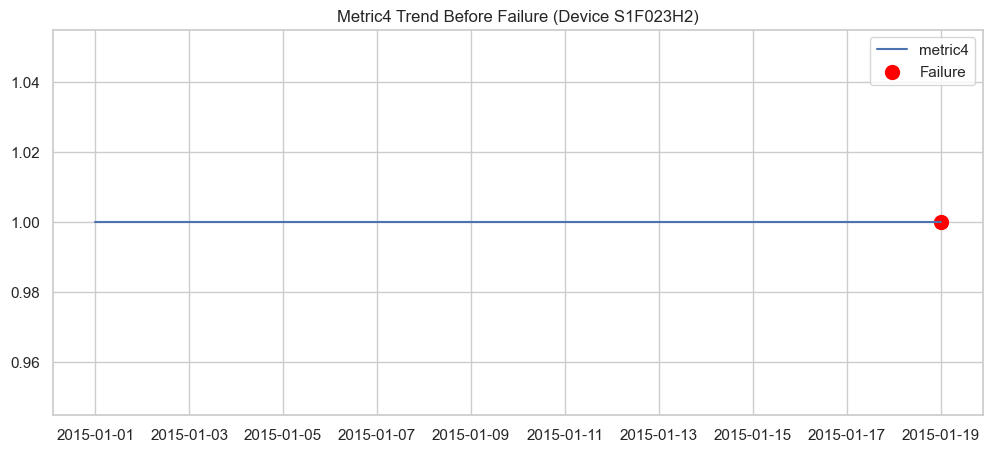

In [77]:
device_id = pre_failure['device'].iloc[0]
device_data = df[df['device'] == device_id]

plt.figure(figsize=(12,5))
plt.plot(device_data['date'], device_data['metric4'], label='metric4')

plt.scatter(device_data[device_data['failure']==1]['date'],
            device_data[device_data['failure']==1]['metric4'],
            color='red', s=100, label='Failure')

plt.title(f"Metric4 Trend Before Failure (Device {device_id})")
plt.legend()
plt.show()

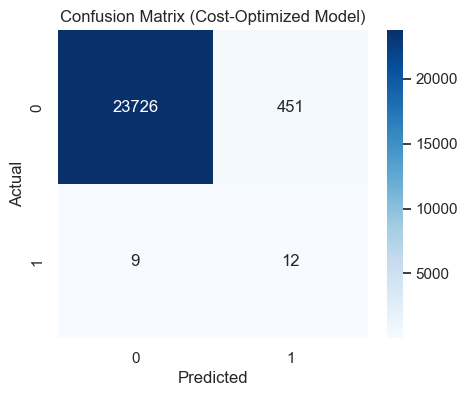

In [78]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Cost-Optimized Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

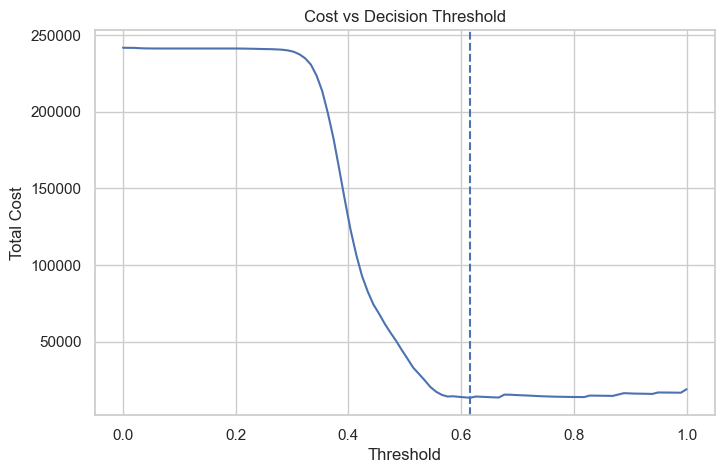

In [79]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, linestyle='--')
plt.title("Cost vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.show()

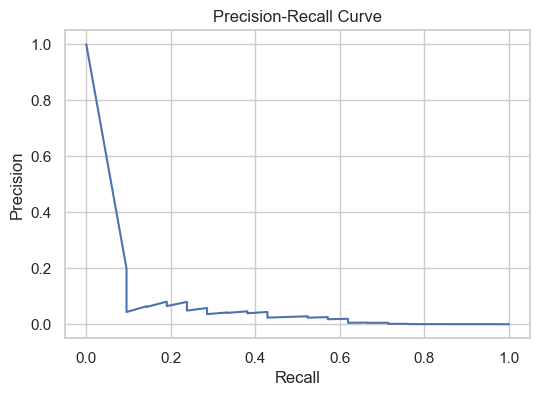

In [80]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Final Conclusion

## Problem Solved
Developed a predictive maintenance system for IoT devices with extremely rare failure events.

##  Key Achievements

- Captured pre-failure patterns using lag features
- Handled extreme class imbalance effectively
- Implemented cost-based threshold optimization
- Reduced operational cost by **~68%**


##  Business Impact

- Reduced unnecessary maintenance actions
- Improved failure detection capability
- Enabled data-driven maintenance decisions


##  Key Learnings

- Accuracy is not suitable for imbalanced problems
- Temporal features are critical in IoT systems
- Business-aware ML (cost optimization) is essential

## Final Statement

This project demonstrates how machine learning can be aligned with business objectives to create a scalable, cost-efficient predictive maintenance solution in an Industry 4.0 environment.